In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

In [2]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman"]
plt.rcParams["font.size"] = 20

plt.rcParams["mathtext.fontset"] = "stix"

### Transmonin määrittely

In [3]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [4]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [5]:
c_guess_vals=[0.9791281505684851]
A_vals=[3.4342536609022134]

s1_middle = 29.38287190734891
s2_middle = 33.2771424252014

In [6]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4

dim = 20

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [7]:
def find_drive_frequency(A,f_supp,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        delta=qubit.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 3.3:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=15,f_2=f_2_shifted,K=200, drag=True)
        elif A < 3.8:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=10,f_2=f_2_shifted,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2_shifted,K=200, drag=True)
        
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

def find_params(f_1,f_2,A,evolution,f_rabi,lims,scales,verbose=True):

    #Rajat AC-stark siirtymälle
    min_range_s1 = lims[0][0]
    max_range_s1 = lims[0][1]

    min_range_s2 = lims[1][0]
    max_range_s2 = lims[1][1]
    
    e_data=[]
    f_data=[]

    s1_vals=np.arange(min_range_s1,max_range_s1)/scales[0] + s1_middle
    s2_vals=np.arange(min_range_s2,max_range_s2)/scales[1] + s2_middle
    
    for i in range(min_range_s1,max_range_s1):
        s1 = i/scales[0] + s1_middle
        
        max_e_vals=[]
        max_f_vals=[]
        
        for j in range(min_range_s2,max_range_s2):

            s2 = j/scales[1] + s2_middle
    
            sim_vals = pulses.sim_3_part_pulses(f_1,[s1,s2],A,evolution,dim,f_rabi,t_ramp=10,U_f=1,f_2=f_2,K=200,drag=True)

            max_e_vals.append(sim_vals[0])
            max_f_vals.append(sim_vals[1])

        e_data.append(max_e_vals)
        f_data.append(max_f_vals)

    xtick_locs=np.arange(0,1, step=0.2)*len(s1_vals)
    ytick_locs=np.arange(0,1, step=0.2)*len(s2_vals)

    xlabels=[round(s1_vals[int(i)],3) for i in xtick_locs]
    ylabels=[round(s2_vals[int(i)],3) for i in ytick_locs]

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(e_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_s1")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_s2")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="e-tason suurin todennäköisyys")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(f_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_s1")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_s2")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="f-tason suurin todennäköisyys")
    plt.show()

    if verbose:
        print(e_data)
        print(f_data)

    min_index = np.unravel_index(np.argmin(f_data), np.array(f_data).shape)
    
    s1=s1_vals[min_index[0]]
    s2=s2_vals[min_index[1]]
    
    return(s1,s2)

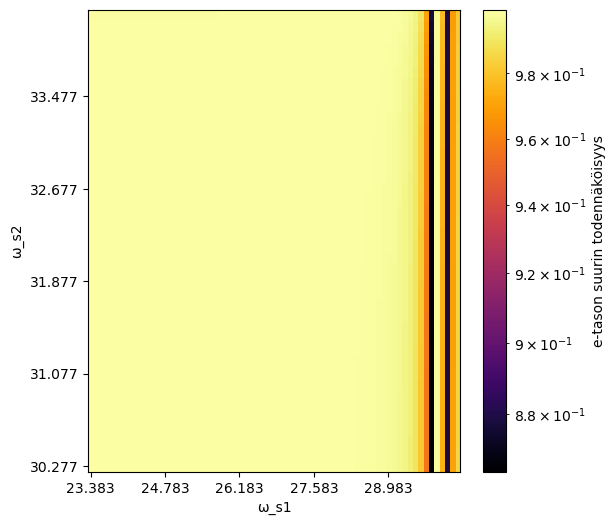

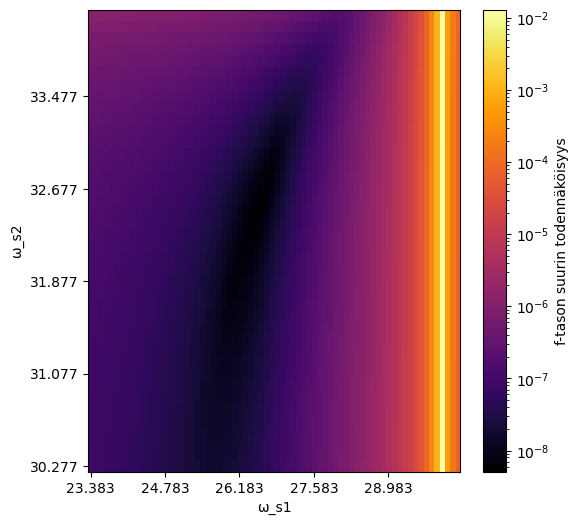

[[np.float64(0.9999362835404554), np.float64(0.9999369027365754), np.float64(0.9999375126871292), np.float64(0.9999381101672354), np.float64(0.9999386914013747), np.float64(0.9999392519678076), np.float64(0.9999397866834158), np.float64(0.9999402894649656), np.float64(0.9999407531637352), np.float64(0.999941169364471), np.float64(0.9999415281416363), np.float64(0.9999418177630653), np.float64(0.9999420243264093), np.float64(0.9999421313132836), np.float64(0.9999421190362341), np.float64(0.9999419639532839), np.float64(0.999941637809857), np.float64(0.999941106560079), np.float64(0.9999403289999366), np.float64(0.9999392550257836), np.float64(0.9999378233953972), np.float64(0.9999359588295815), np.float64(0.9999335682226314), np.float64(0.9999305356477458), np.float64(0.9999267156990035), np.float64(0.9999219245247615), np.float64(0.9999159276014987), np.float64(0.9999084228473936), np.float64(0.9998990169609389), np.float64(0.9998871917411164), np.float64(0.9998722553050684), np.float6

Amplitudi (GHz): 3.4342536609022134
Ensimmäinen hiljennetty taajuus (10⁹ rad/s): 26.68287190734891
Toinen hiljennetty taajuus (10⁹ rad/s): 32.677142425201396
E-tason suurin todennäköisyys: 0.9999329014974507
F-tason suurin todennäköisyys: 5.0789663435736995e-09


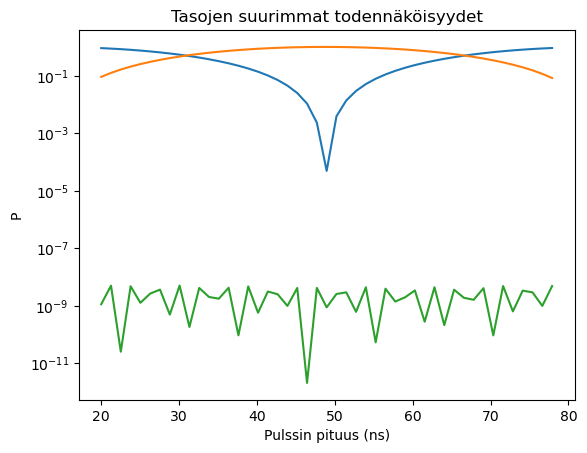

---------------------------------------------


In [ ]:
A=A_vals[0]
f_rabi=2*np.pi/60

s1_vals=[]
s2_vals=[]

params=find_params(f_1*c_guess_vals[0],f_2*c_guess_vals[0],A,evolution_eigenbasis,f_rabi,[[-60,10],[-30,10]],[10,10])
s1_vals.append(params[0])
s2_vals.append(params[1])

m=1

vals = pulses.sim_3_part_pulses(f_1*c_guess_vals[0],[s1_vals[-1],s2_vals[-1]],A,evolution_eigenbasis,dim,f_rabi/m,f_2=f_2*c_guess_vals[0],t_ramp=10,U_f=1,K=200,drag=True)

print("Amplitudi (GHz):", A)

print("Ensimmäinen hiljennetty taajuus (10⁹ rad/s):", s1_vals[-1])
print("Toinen hiljennetty taajuus (10⁹ rad/s):", s2_vals[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

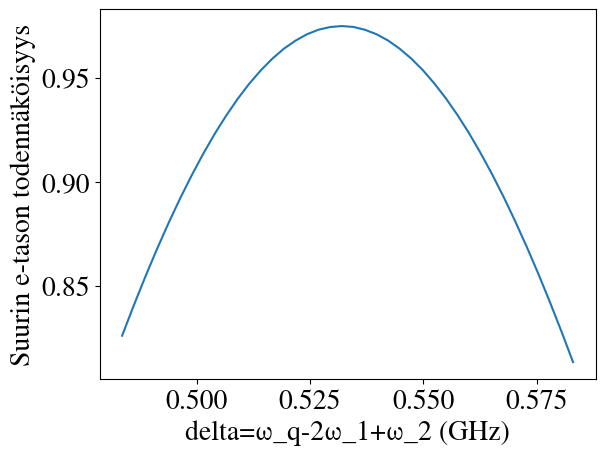

Amplitudi (GHz): 3.4342536609022134
AC-stark siirtymä (GHz): 0.5319942504217248
E-tason suurin todennäköisyys: 0.9999344605580248
F-tason suurin todennäköisyys: 5.325564298808764e-09
Pulssin pituus (ns): 45.17644033967621


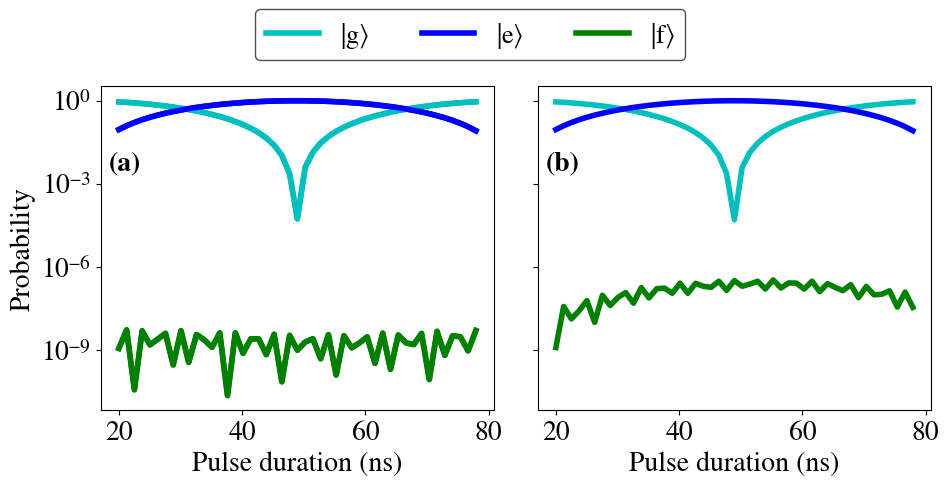

In [12]:
f_rabi = 2*np.pi/60
m = 1

params = find_drive_frequency(
    3.4342536609022134,
    [26.68287190734891, 32.677142425201396],
    evolution_eigenbasis,
    f_rabi,
    c_guess_vals[0],
    [-20, 20],
    10000
)

c_opt = params[0]

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 5))

colors = ['c', 'b', 'g']

vals_a = pulses.sim_3_part_pulses(
    f_1*c_opt,
    [26.68287190734891, 32.677142425201396],
    3.4342536609022134,
    evolution_eigenbasis,
    dim,
    f_rabi/m,
    f_2=f_2*c_opt,
    t_ramp=10,
    U_f=1,
    K=200,
    drag=True
)

g_vals = np.array([arr[0] for arr in vals_a[3]])
e_vals = np.array([arr[1] for arr in vals_a[3]])
f_vals = np.array([arr[2] for arr in vals_a[3]])
h1_vals = np.array([arr[3] for arr in vals_a[3]])
h2_vals = np.array([arr[4] for arr in vals_a[3]])
h3_vals = np.array([arr[5] for arr in vals_a[3]])
h4_vals = np.array([arr[6] for arr in vals_a[3]])

n_picked = int(len(vals_a[3]) / m)

l1, = axes[0].semilogy(vals_a[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
l2, = axes[0].semilogy(vals_a[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
l3, = axes[0].semilogy(vals_a[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')

axes[0].semilogy(vals_a[4][:n_picked], g_vals[:n_picked], linewidth=4, color=colors[0])
axes[0].semilogy(vals_a[4][:n_picked], e_vals[:n_picked], linewidth=4, color=colors[1])
axes[0].semilogy(vals_a[4][:n_picked], f_vals[:n_picked], linewidth=4, color=colors[2])
#axes[0].semilogy(vals_a[4][:n_picked], h1_vals[:n_picked], linewidth=4)
#axes[0].semilogy(vals_a[4][:n_picked], h2_vals[:n_picked], linewidth=4)
#axes[0].semilogy(vals_a[4][:n_picked], h3_vals[:n_picked], linewidth=4)
#axes[0].semilogy(vals_a[4][:n_picked], h4_vals[:n_picked], linewidth=4)

axes[0].set_xlabel("Pulse duration (ns)")
axes[0].set_ylabel("Probability")
#axes[0].legend([r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "3", "4", "5", "6"],loc="upper right")

axes[0].text(0.02, 0.80, "(a)",
             transform=axes[0].transAxes,
             va="top",
             fontweight="bold")

print("Amplitudi (GHz):", 3.4342536609022134)
print("AC-stark siirtymä (GHz):", 2*f_1*(1-c_opt)-f_2*(1-c_opt))
print("E-tason suurin todennäköisyys:", vals_a[0])
print("F-tason suurin todennäköisyys:", vals_a[1])
print("Pulssin pituus (ns):", params[1])

vals_b = pulses.sim_3_part_pulses(
    f_1*c_opt,
    [26.68287190734891, 32.677142425201396],
    3.4342536609022134,
    evolution_eigenbasis,
    dim,
    f_rabi/m,
    f_2=f_2*c_opt,
    t_ramp=10,
    U_f=1,
    K=200,
    drag=False
)

g_vals = np.array([arr[0] for arr in vals_b[3]])
e_vals = np.array([arr[1] for arr in vals_b[3]])
f_vals = np.array([arr[2] for arr in vals_b[3]])
h1_vals = np.array([arr[3] for arr in vals_b[3]])
h2_vals = np.array([arr[4] for arr in vals_b[3]])
h3_vals = np.array([arr[5] for arr in vals_b[3]])
h4_vals = np.array([arr[6] for arr in vals_b[3]])

n_picked = int(len(vals_b[3]) / m)

axes[1].semilogy(vals_b[4][:n_picked], g_vals[:n_picked], linewidth=4, color=colors[0])
axes[1].semilogy(vals_b[4][:n_picked], e_vals[:n_picked], linewidth=4, color=colors[1])
axes[1].semilogy(vals_b[4][:n_picked], f_vals[:n_picked], linewidth=4, color=colors[2])
#axes[1].semilogy(vals_b[4][:n_picked], h1_vals[:n_picked], linewidth=4)
#axes[1].semilogy(vals_b[4][:n_picked], h2_vals[:n_picked], linewidth=4)
#axes[1].semilogy(vals_b[4][:n_picked], h3_vals[:n_picked], linewidth=4)
#axes[1].semilogy(vals_b[4][:n_picked], h4_vals[:n_picked], linewidth=4)

axes[1].set_xlabel("Pulse duration (ns)")
#axes[1].legend([r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "3", "4", "5", "6"],loc="upper right")

axes[1].text(0.02, 0.80, "(b)",
             transform=axes[1].transAxes,
             va="top",
             fontweight="bold")

fig.legend(
    [l1, l2, l3],
    [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=19,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

plt.tight_layout(rect=[0, 0, 1, 0.9])

plt.savefig("2f-pulses.pdf")
plt.show()

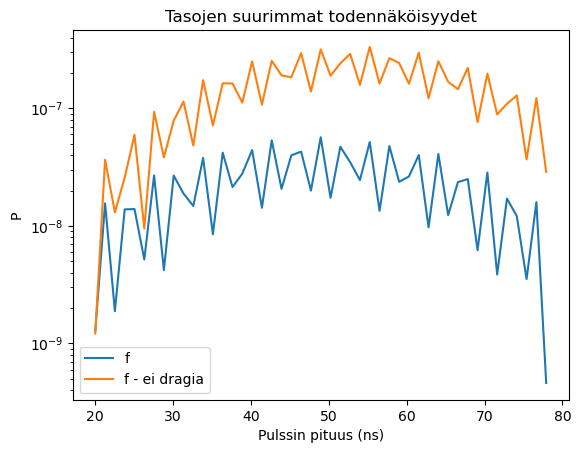

---------------------------------------------


In [17]:
A=A_vals[0]
f_rabi=2*np.pi/60

m=1

vals = pulses.sim_3_part_pulses(f_1*c_guess_vals[0],[24.400000000000002,60],A,evolution_eigenbasis,dim,f_rabi,f_2=f_2*c_guess_vals[0],t_ramp=10,U_f=1,K=200,drag=False)
f_vals_2=np.array([arr[2] for arr in vals[3]])
vals = pulses.sim_3_part_pulses(f_1*c_guess_vals[0],[24.400000000000002,100000000000],A,evolution_eigenbasis,dim,f_rabi,f_2=f_2*c_guess_vals[0],t_ramp=10,U_f=1,K=200,drag=True)
f_vals_1=np.array([arr[2] for arr in vals[3]])


n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], f_vals_1[:n_picked], label="f")
plt.semilogy(vals[4][:n_picked], f_vals_2[:n_picked], label="f - ei dragia")

plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.legend()
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")